# Stellar Classification — Preprocessing Pipeline

**Notebook:** `02_preprocessing.ipynb`  
**Depends on:** `01_eda.ipynb` (data exploration complete)  
**Output:** Scaled train/test splits + fitted pipelines saved to `output/`

---

## Purpose

This notebook formalises the data preparation steps informed by the EDA:

- Clean the raw dataset (duplicates, outlier check)
- Define two feature sets: **full** (with `redshift`) and **photometric-only** (without)
- Fit a `scikit-learn` preprocessing pipeline for each feature set
- Perform a stratified 80/20 train/test split
- Save all artefacts to `output/` so `03_models.ipynb` can load them directly

> The two-feature-set design directly mirrors the core experiment:
> *how much does removing `redshift` degrade classification performance?*

---
## 1. Setup & Imports

In [14]:
import sys
from pathlib import Path

BACKEND_DIR = Path().resolve()
DATA_PATH = BACKEND_DIR.parent / 'data' / 'star_classification.csv'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from utils.logger import setup_logger
from utils.pipeline import (
    load_data,
    get_feature_list,
    encode_target,
    build_pipeline,
    prepare_train_test,
    TARGET_MAPPING,
)

OUTPUT_DIR = BACKEND_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

logger = setup_logger('02_preprocessing')
logger.info('Preprocessing notebook started')
print('Backend dir:', BACKEND_DIR)

print("BACKEND_DIR:", BACKEND_DIR)
print("DATA_PATH exists:", DATA_PATH.exists())

[2026-04-20 15:46:28] [INFO] Logger initialised | script=02_preprocessing | log=run_20260420_154628_02_preprocessing.log
[2026-04-20 15:46:28] [INFO] Preprocessing notebook started


Backend dir: /Users/nikitadackov/PycharmProjects/JupyterProject/BackEnd
BACKEND_DIR: /Users/nikitadackov/PycharmProjects/JupyterProject/BackEnd
DATA_PATH exists: True


---
## 2. Load Data

In [15]:
df = load_data(DATA_PATH)
logger.info(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Shape: {df.shape}')
df.head()

[2026-04-20 15:46:29] [INFO] Dataset loaded: 100,000 rows, 18 columns


Shape: (100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


---
## 3. Data Cleaning

Minimal cleaning — we avoid aggressive filtering to preserve the natural
distribution of the dataset. EDA showed no missing values.
Here we check for duplicates and flag obvious sensor artefacts
(SDSS encodes failed measurements as `-9999`).

In [16]:
# Duplicates
dup_count = df.duplicated().sum()
logger.info(f'Duplicated rows: {dup_count}')
print(f'Duplicated rows: {dup_count}')

if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    logger.info(f'Duplicates removed. New shape: {df.shape}')
    print(f'After dedup: {df.shape}')

[2026-04-20 15:46:49] [INFO] Duplicated rows: 0


Duplicated rows: 0


In [17]:
# SDSS encodes failed photometric measurements as -9999
# These are sensor artefacts, not real astronomical values
SENTINEL = -9999
photometric_cols = ['u', 'g', 'r', 'i', 'z']

sentinel_mask = (df[photometric_cols] == SENTINEL).any(axis=1)
sentinel_count = sentinel_mask.sum()
logger.info(f'Rows with sentinel value ({SENTINEL}): {sentinel_count}')
print(f'Rows with sentinel value ({SENTINEL}): {sentinel_count}')

if sentinel_count > 0:
    df = df[~sentinel_mask].reset_index(drop=True)
    logger.info(f'Sentinel rows removed. New shape: {df.shape}')
    print(f'After sentinel removal: {df.shape}')

[2026-04-20 15:46:51] [INFO] Rows with sentinel value (-9999): 1
[2026-04-20 15:46:51] [INFO] Sentinel rows removed. New shape: (99999, 18)


Rows with sentinel value (-9999): 1
After sentinel removal: (99999, 18)


In [18]:
# Final shape after cleaning
logger.info(f'Clean dataset shape: {df.shape}')
print(f'\nFinal clean dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
df[['u', 'g', 'r', 'i', 'z', 'redshift']].describe().round(3)

[2026-04-20 15:46:52] [INFO] Clean dataset shape: (99999, 18)



Final clean dataset: 99,999 rows, 18 columns


,u,g,r,i,z,redshift
count,99999.000,99999.000,99999.000,99999.000,99999.000,99999.000
mean,22.081,20.632,19.646,19.085,18.769,0.577
std,2.251,2.037,1.855,1.758,1.766,0.731
min,10.996,10.498,9.822,9.470,9.612,-0.010
25%,20.352,18.965,18.136,17.732,17.461,0.055
50%,22.179,21.100,20.125,19.405,19.005,0.424
75%,23.687,22.124,21.045,20.397,19.921,0.704
max,32.781,31.602,29.572,32.141,29.384,7.011


---
## 4. Feature Sets

Two feature sets are defined here and used consistently across all subsequent notebooks.

| Set | Features | Purpose |
|-----|----------|---------|
| **Full** | u, g, r, i, z, alpha, delta, **redshift** | Primary model — realistic spectroscopic pipeline |
| **Photometric-only** | u, g, r, i, z, alpha, delta | Experiment — simulates redshift-unavailable scenario |

The difference in model accuracy between these two sets is the
central scientific finding of this project.

In [19]:
features_full = get_feature_list(include_redshift=True)
features_no_z = get_feature_list(include_redshift=False)

print('Full feature set:         ', features_full)
print('Photometric-only set:     ', features_no_z)
print(f'\nFeatures dropped in experiment: redshift')
logger.info(f'Full features: {features_full}')
logger.info(f'No-redshift features: {features_no_z}')

[2026-04-20 15:46:53] [INFO] Full features: ['u', 'g', 'r', 'i', 'z', 'alpha', 'delta', 'redshift']
[2026-04-20 15:46:53] [INFO] No-redshift features: ['u', 'g', 'r', 'i', 'z', 'alpha', 'delta']


Full feature set:          ['u', 'g', 'r', 'i', 'z', 'alpha', 'delta', 'redshift']
Photometric-only set:      ['u', 'g', 'r', 'i', 'z', 'alpha', 'delta']

Features dropped in experiment: redshift


In [20]:
# Target encoding — what the models will predict
print('Target encoding:', TARGET_MAPPING)
print()
print('Class distribution in clean dataset:')
print(df['class'].value_counts())
logger.info(f'Target mapping: {TARGET_MAPPING}')

[2026-04-20 15:46:54] [INFO] Target mapping: {'STAR': 0, 'GALAXY': 1, 'QSO': 2}


Target encoding: {'STAR': 0, 'GALAXY': 1, 'QSO': 2}

Class distribution in clean dataset:
class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64


---
## 5. Train / Test Split & Preprocessing

Both feature sets go through the same process:
1. Select relevant columns
2. Encode target (`STAR=0`, `GALAXY=1`, `QSO=2`)
3. Stratified 80/20 split (preserves class ratios in both sets)
4. `StandardScaler` fitted on training data only — **never** on test data

> Fitting the scaler only on `X_train` prevents data leakage.
> The same fitted scaler is then applied to `X_test`.

In [21]:
# ── Full feature set (with redshift) ──────────────────────────────────────
X_train_full, X_test_full, y_train_full, y_test_full, pipe_full = prepare_train_test(
    df,
    include_redshift=True,
    test_size=0.2,
    random_state=42,
)

logger.info(f'Full: X_train={X_train_full.shape}, X_test={X_test_full.shape}')
print(f'Full feature set:')
print(f'  X_train: {X_train_full.shape}  X_test: {X_test_full.shape}')
print(f'  y_train: {y_train_full.shape}  y_test: {y_test_full.shape}')

[2026-04-20 15:46:55] [INFO] Full: X_train=(79999, 8), X_test=(20000, 8)


Full feature set:
  X_train: (79999, 8)  X_test: (20000, 8)
  y_train: (79999,)  y_test: (20000,)


In [22]:
# ── Photometric-only set (without redshift) ────────────────────────────────
X_train_noz, X_test_noz, y_train_noz, y_test_noz, pipe_noz = prepare_train_test(
    df,
    include_redshift=False,
    test_size=0.2,
    random_state=42,
)

logger.info(f'No-redshift: X_train={X_train_noz.shape}, X_test={X_test_noz.shape}')
print(f'Photometric-only set:')
print(f'  X_train: {X_train_noz.shape}  X_test: {X_test_noz.shape}')
print(f'  y_train: {y_train_noz.shape}  y_test: {y_test_noz.shape}')

[2026-04-20 15:46:56] [INFO] No-redshift: X_train=(79999, 7), X_test=(20000, 7)


Photometric-only set:
  X_train: (79999, 7)  X_test: (20000, 7)
  y_train: (79999,)  y_test: (20000,)


---
## 6. Class Balance Verification

Verify that stratified splitting preserved class ratios in both train and test sets.

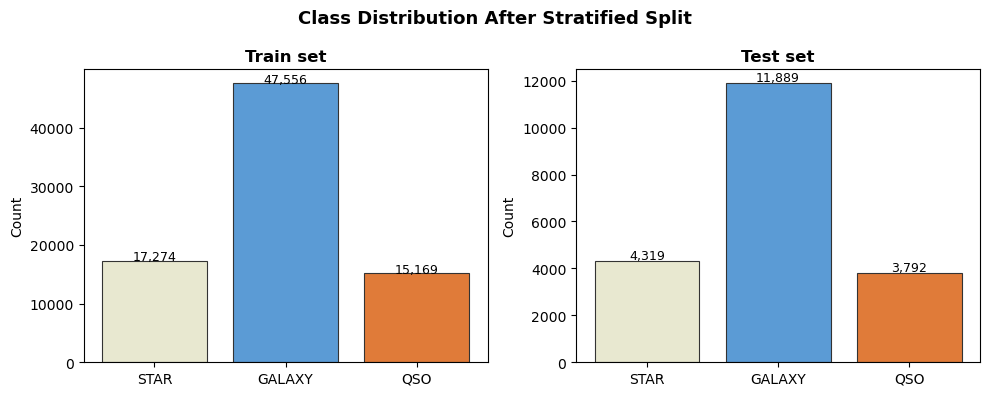

Train class ratios:
  STAR: 17,274 (21.6%)
  GALAXY: 47,556 (59.4%)
  QSO: 15,169 (19.0%)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

CLASS_NAMES = {0: 'STAR', 1: 'GALAXY', 2: 'QSO'}
PALETTE = ['#e8e8d0', '#5b9bd5', '#e07b39']

for ax, y, title in zip(axes, [y_train_full, y_test_full], ['Train set', 'Test set']):
    unique, counts = np.unique(y, return_counts=True)
    labels = [CLASS_NAMES[u] for u in unique]
    ax.bar(labels, counts, color=PALETTE, edgecolor='#333', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, (lbl, cnt) in enumerate(zip(labels, counts)):
        ax.text(i, cnt + 100, f'{cnt:,}', ha='center', fontsize=9)

plt.suptitle('Class Distribution After Stratified Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preprocessing_class_split.png', bbox_inches='tight')
plt.show()

# Percentage check
print('Train class ratios:')
for cls, cnt in zip(*np.unique(y_train_full, return_counts=True)):
    print(f'  {CLASS_NAMES[cls]}: {cnt:,} ({cnt/len(y_train_full)*100:.1f}%)')

---
## 7. Save Artefacts

`03_models.ipynb` will load these files directly — no need to re-run
preprocessing every time.

| File | Contents |
|------|----------|
| `preprocess_full.joblib` | Fitted `StandardScaler` pipeline — full features |
| `preprocess_no_redshift.joblib` | Fitted `StandardScaler` pipeline — no redshift |
| `dataset_full.npz` | `X_train`, `X_test`, `y_train`, `y_test` — full features |
| `dataset_no_redshift.npz` | `X_train`, `X_test`, `y_train`, `y_test` — no redshift |

In [24]:
# Save fitted pipelines
joblib.dump(pipe_full, OUTPUT_DIR / 'preprocess_full.joblib')
joblib.dump(pipe_noz,  OUTPUT_DIR / 'preprocess_no_redshift.joblib')
logger.info('Pipelines saved to output/')
print('Pipelines saved:')
print(' ', OUTPUT_DIR / 'preprocess_full.joblib')
print(' ', OUTPUT_DIR / 'preprocess_no_redshift.joblib')

[2026-04-20 15:46:59] [INFO] Pipelines saved to output/


Pipelines saved:
  /Users/nikitadackov/PycharmProjects/JupyterProject/BackEnd/output/preprocess_full.joblib
  /Users/nikitadackov/PycharmProjects/JupyterProject/BackEnd/output/preprocess_no_redshift.joblib


In [25]:
# Save train/test splits as compressed numpy arrays
np.savez_compressed(
    OUTPUT_DIR / 'dataset_full.npz',
    X_train=X_train_full,
    X_test=X_test_full,
    y_train=y_train_full,
    y_test=y_test_full,
)

np.savez_compressed(
    OUTPUT_DIR / 'dataset_no_redshift.npz',
    X_train=X_train_noz,
    X_test=X_test_noz,
    y_train=y_train_noz,
    y_test=y_test_noz,
)

logger.info('Train/test splits saved to output/')
print('\nDatasets saved:')
print(' ', OUTPUT_DIR / 'dataset_full.npz')
print(' ', OUTPUT_DIR / 'dataset_no_redshift.npz')

[2026-04-20 15:47:00] [INFO] Train/test splits saved to output/



Datasets saved:
  /Users/nikitadackov/PycharmProjects/JupyterProject/BackEnd/output/dataset_full.npz
  /Users/nikitadackov/PycharmProjects/JupyterProject/BackEnd/output/dataset_no_redshift.npz


In [26]:
# Verify saved files
saved = list(OUTPUT_DIR.glob('*.npz')) + list(OUTPUT_DIR.glob('*.joblib'))
print('\nFiles in output/:')
for f in sorted(saved):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<40} {size_kb:.1f} KB')
logger.info('Preprocessing complete — all artefacts saved')

[2026-04-20 15:47:00] [INFO] Preprocessing complete — all artefacts saved



Files in output/:
  dataset_full.npz                         6009.3 KB
  dataset_no_redshift.npz                  5268.4 KB
  preprocess_full.joblib                   1.9 KB
  preprocess_no_redshift.joblib            1.8 KB


---
## 8. Summary

### What was done
- Removed duplicate rows (if any) and SDSS sentinel values (`-9999`)
- Defined two feature sets: **full** (8 features) and **photometric-only** (7 features)
- Fitted a `StandardScaler` pipeline on training data for each feature set
- Performed stratified 80/20 train/test split — class ratios preserved
- Saved all artefacts to `backend/output/`

### What's next
`03_models.ipynb` — train **KNN** (baseline) and **Random Forest** (primary model)
on both feature sets, compare accuracy and confusion matrices.

The key question to answer: *how much accuracy does the model lose without `redshift`?*